# Customer Churn Analysis — Telecom Subscription Business

**Goal:** Identify *who* is churning, *why*, and *how much revenue is at risk* — then turn that into concrete retention recommendations.

**Tools:** SQL (SQLite) for business-question querying · pandas/NumPy for analysis · Matplotlib for visual storytelling

**Structure:**
1. Data generation & loading into a SQL database
2. SQL exploration — answering business questions directly with queries
3. Pandas/NumPy deep-dive — cohorts, correlations, segment analysis
4. Visualizations that tell the story
5. Key findings & business recommendations
6. (Bonus) A simple churn risk score

## 1. Setup

In [128]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 10

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

RNG = np.random.default_rng(42)

## 2. Generate a realistic customer dataset

In a real job you'd pull this from a company's data warehouse. Here we simulate ~6,000 telecom
subscribers with realistic churn drivers baked in, so the patterns we "discover" later are genuine
and explainable — the same way real churn data behaves:

- Month-to-month contracts churn far more than annual contracts (no lock-in)
- Customers with **no tech support** churn more (frustration, unresolved issues)
- **Fiber optic** internet churns more than DSL (often pricier, more competitors)
- Churn risk is highest in the **first 12 months** and drops the longer someone stays
- Higher monthly bills increase churn risk, especially for new/low-tenure customers
- Customers on automatic payment methods churn less (friction to leave is higher)

In [129]:
N = 6000

contract = RNG.choice(
    ["Month-to-month", "One year", "Two year"], size=N, p=[0.55, 0.25, 0.20]
)
internet_service = RNG.choice(
    ["Fiber optic", "DSL", "No internet"], size=N, p=[0.45, 0.35, 0.20]
)
tech_support = np.where(
    internet_service == "No internet", "No internet",
    RNG.choice(["Yes", "No"], size=N, p=[0.4, 0.6])
)
payment_method = RNG.choice(
    ["Electronic check", "Mailed check", "Bank transfer (auto)", "Credit card (auto)"],
    size=N, p=[0.35, 0.20, 0.225, 0.225]
)
senior_citizen = RNG.choice([0, 1], size=N, p=[0.84, 0.16])
partner = RNG.choice(["Yes", "No"], size=N, p=[0.48, 0.52])
paperless_billing = RNG.choice(["Yes", "No"], size=N, p=[0.59, 0.41])

# tenure: skewed toward newer customers (typical of growing subscriber bases)
tenure_months = np.clip(RNG.exponential(scale=22, size=N).astype(int), 0, 72)

# monthly charges depend on internet service + tech support
base_charge = np.select(
    [internet_service == "Fiber optic", internet_service == "DSL", internet_service == "No internet"],
    [RNG.normal(85, 12, N), RNG.normal(58, 10, N), RNG.normal(21, 5, N)]
)
base_charge += np.where(tech_support == "Yes", 8, 0)
monthly_charges = np.clip(base_charge, 18, 130).round(2)

total_charges = (monthly_charges * np.maximum(tenure_months, 1) * RNG.uniform(0.92, 1.0, N)).round(2)

# ---- Churn probability model (logistic combination of realistic risk factors) ----
logit = (
    -1.4
    + np.where(contract == "Month-to-month", 1.6, np.where(contract == "One year", 0.1, -1.0))
    + np.where(internet_service == "Fiber optic", 0.55, np.where(internet_service == "DSL", 0.0, -0.9))
    + np.where(tech_support == "No", 0.5, 0.0)
    + np.where(payment_method == "Electronic check", 0.45, 0.0)
    + np.where(np.char.find(payment_method.astype(str), "auto") >= 0, -0.35, 0.0)
    - 0.035 * tenure_months
    + 0.012 * (monthly_charges - 60)
    + np.where(senior_citizen == 1, 0.25, 0.0)
    + np.where(partner == "No", 0.2, 0.0)
    + RNG.normal(0, 0.55, N)  # noise so it isn't a perfectly separable toy problem
)
churn_prob = 1 / (1 + np.exp(-logit))
churn = (RNG.uniform(0, 1, N) < churn_prob).astype(int)
churn_label = np.where(churn == 1, "Yes", "No")

customer_id = [f"CUST-{100000+i}" for i in range(N)]
signup_date = pd.Timestamp("2026-07-01") - pd.to_timedelta(tenure_months * 30, unit="D")

df = pd.DataFrame({
    "customer_id": customer_id,
    "signup_date": signup_date.date,
    "tenure_months": tenure_months,
    "contract": contract,
    "internet_service": internet_service,
    "tech_support": tech_support,
    "payment_method": payment_method,
    "paperless_billing": paperless_billing,
    "senior_citizen": senior_citizen,
    "partner": partner,
    "monthly_charges": monthly_charges,
    "total_charges": total_charges,
    "churn": churn_label,
})

df.to_csv("telecom_customers.csv", index=False)
print(f"Generated {len(df):,} customer records")
df.head()

Generated 6,000 customer records


,customer_id,signup_date,tenure_months,contract,internet_service,tech_support,payment_method,paperless_billing,senior_citizen,partner,monthly_charges,total_charges,churn
0,CUST-100000,2025-03-08,16,One year,DSL,No,Electronic check,No,0,Yes,52.56,838.13,Yes
1,CUST-100001,2025-05-07,14,Month-to-month,Fiber optic,Yes,Credit card (auto),Yes,0,Yes,94.04,1291.25,Yes
2,CUST-100002,2025-08-05,11,Two year,DSL,Yes,Credit card (auto),Yes,0,No,75.37,823.20,No
3,CUST-100003,2023-04-18,39,One year,Fiber optic,No,Mailed check,Yes,0,Yes,79.39,2932.71,No
4,CUST-100004,2025-10-04,9,Month-to-month,Fiber optic,Yes,Credit card (auto),Yes,0,Yes,90.93,763.86,Yes


## 3. Load into a SQL database

We'll use SQLite so the whole project is self-contained and reproducible — no external server
needed, but the SQL you write is standard and transfers directly to Postgres/MySQL/etc.

In [130]:
conn = sqlite3.connect("churn.db")
df.to_sql("customers", conn, if_exists="replace", index=False)

pd.read_sql("SELECT COUNT(*) AS total_rows FROM customers;", conn)

,total_rows
0,6000


### 3.1 Overall churn rate

In [131]:
query = """
SELECT
    COUNT(*) AS total_customers,
    SUM(CASE WHEN churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(100.0 * SUM(CASE WHEN churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS churn_rate_pct
FROM customers;
"""
overall_churn = pd.read_sql(query, conn)
overall_churn

,total_customers,churned_customers,churn_rate_pct
0,6000,2208,36.8


### 3.2 Churn rate by contract type
This is almost always the single biggest churn driver in subscription businesses — worth checking first.

In [132]:
query = """
SELECT
    contract,
    COUNT(*) AS customers,
    SUM(CASE WHEN churn = 'Yes' THEN 1 ELSE 0 END) AS churned,
    ROUND(100.0 * SUM(CASE WHEN churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS churn_rate_pct
FROM customers
GROUP BY contract
ORDER BY churn_rate_pct DESC;
"""
churn_by_contract = pd.read_sql(query, conn)
churn_by_contract

,contract,customers,churned,churn_rate_pct
0,Month-to-month,3345,1709,51.09
1,One year,1482,369,24.90
2,Two year,1173,130,11.08


### 3.3 Churn rate by tenure bucket
Uses a `CASE WHEN` to bucket tenure directly in SQL — this is a very common interview-style query.

In [133]:
query = """
SELECT
    CASE
        WHEN tenure_months < 6  THEN '0-5 months'
        WHEN tenure_months < 12 THEN '6-11 months'
        WHEN tenure_months < 24 THEN '1-2 years'
        WHEN tenure_months < 48 THEN '2-4 years'
        ELSE '4+ years'
    END AS tenure_bucket,
    COUNT(*) AS customers,
    ROUND(100.0 * SUM(CASE WHEN churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS churn_rate_pct
FROM customers
GROUP BY tenure_bucket
ORDER BY MIN(tenure_months);
"""
churn_by_tenure = pd.read_sql(query, conn)
churn_by_tenure

,tenure_bucket,customers,churn_rate_pct
0,0-5 months,1431,45.98
1,6-11 months,1090,42.94
2,1-2 years,1454,37.07
3,2-4 years,1358,31.96
4,4+ years,667,16.34


### 3.4 Revenue at risk
Churn rate alone can be misleading — a business cares more about **revenue lost**, not headcount.
This query finds monthly recurring revenue currently walking out the door.

In [134]:
query = """
SELECT
    ROUND(SUM(CASE WHEN churn = 'Yes' THEN monthly_charges ELSE 0 END), 2) AS mrr_lost_to_churn,
    ROUND(SUM(monthly_charges), 2) AS total_mrr,
    ROUND(100.0 * SUM(CASE WHEN churn = 'Yes' THEN monthly_charges ELSE 0 END) / SUM(monthly_charges), 2) AS pct_of_mrr_at_risk
FROM customers;
"""
revenue_at_risk = pd.read_sql(query, conn)
revenue_at_risk

,mrr_lost_to_churn,total_mrr,pct_of_mrr_at_risk
0,166255.36,393357.52,42.27


### 3.5 High-value customers: are we losing our best accounts?
A window function (`NTILE`) splits customers into revenue quartiles, then we check churn rate
for the **top 25% by monthly spend** — the customers that matter most to the P&L.

In [135]:
query = """
WITH ranked AS (
    SELECT
        *,
        NTILE(4) OVER (ORDER BY monthly_charges) AS spend_quartile
    FROM customers
)
SELECT
    spend_quartile,
    COUNT(*) AS customers,
    ROUND(AVG(monthly_charges), 2) AS avg_monthly_charge,
    ROUND(100.0 * SUM(CASE WHEN churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS churn_rate_pct
FROM ranked
GROUP BY spend_quartile
ORDER BY spend_quartile;
"""
churn_by_spend_quartile = pd.read_sql(query, conn)
churn_by_spend_quartile

,spend_quartile,customers,avg_monthly_charge,churn_rate_pct
0,1,1500,26.98,16.07
1,2,1500,60.60,35.87
2,3,1500,77.86,45.33
3,4,1500,96.80,49.93


### 3.6 Combined risk factors: contract + tech support
Compound conditions like this are exactly how you find your *highest priority* at-risk segment.

In [136]:
query = """
SELECT
    contract,
    tech_support,
    COUNT(*) AS customers,
    ROUND(100.0 * SUM(CASE WHEN churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS churn_rate_pct
FROM customers
WHERE internet_service != 'No internet'
GROUP BY contract, tech_support
ORDER BY churn_rate_pct DESC;
"""
churn_by_contract_support = pd.read_sql(query, conn)
churn_by_contract_support

,contract,tech_support,customers,churn_rate_pct
0,Month-to-month,No,1584,62.18
1,Month-to-month,Yes,1085,54.10
2,One year,No,733,32.20
3,One year,Yes,460,26.96
4,Two year,No,586,16.89
5,Two year,Yes,379,7.12


## 4. Pandas / NumPy deep-dive

Now we pull the full table back into pandas for analysis that's easier to express there than in SQL:
correlations, cohort curves, and segment comparisons.

In [137]:
df = pd.read_sql("SELECT * FROM customers;", conn)
df["churn_flag"] = (df["churn"] == "Yes").astype(int)
df.describe(include="all").T.head(15)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,6000,6000,CUST-105983,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_date,6000,73,2026-07-01,265,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure_months,6000.0,NaN,NaN,NaN,20.622833,18.985705,0.0,6.0,15.0,30.0,72.0
contract,6000,3,Month-to-month,3345,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internet_service,6000,3,Fiber optic,2687,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tech_support,6000,3,No,2903,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_method,6000,4,Electronic check,2070,NaN,NaN,NaN,NaN,NaN,NaN,NaN
paperless_billing,6000,2,Yes,3437,NaN,NaN,NaN,NaN,NaN,NaN,NaN
senior_citizen,6000.0,NaN,NaN,NaN,0.1585,0.36524,0.0,0.0,0.0,0.0,1.0
partner,6000,2,No,3126,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 4.1 Correlation between numeric features and churn
We one-hot encode the key categoricals so we can look at correlation strength on one scale.

In [138]:
encoded = pd.get_dummies(
    df[["tenure_months", "monthly_charges", "total_charges", "senior_citizen",
        "contract", "internet_service", "tech_support", "payment_method", "churn_flag"]],
    drop_first=False
)
corr_with_churn = (
    encoded.corr(numeric_only=True)["churn_flag"]
    .drop("churn_flag")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
corr_with_churn.head(12).to_frame("correlation_with_churn")

,correlation_with_churn
contract_Month-to-month,0.332622
monthly_charges,0.277660
contract_Two year,-0.262877
tech_support_No internet,-0.245449
internet_service_No internet,-0.245449
internet_service_Fiber optic,0.242676
tenure_months,-0.192096
tech_support_No,0.174060
contract_One year,-0.141338
payment_method_Electronic check,0.117222


### 4.2 Cohort retention curve
For each signup cohort (by month), what % of customers are still active as tenure increases?
This is the classic "retention curve" used in every subscription-business board deck.

In [139]:
df["signup_month"] = pd.to_datetime(df["signup_date"]).dt.to_period("M")

retention = (
    df.groupby("tenure_months")["churn_flag"]
    .agg(customers="count", churned="sum")
    .assign(retained_pct=lambda x: 100 * (1 - x["churned"].cumsum() / x["customers"].sum()))
)
retention.head(10)

,customers,churned,retained_pct
tenure_months,,,
0,265,127,97.883333
1,226,101,96.200000
2,259,123,94.150000
3,240,100,92.483333
4,235,101,90.800000
5,206,106,89.033333
6,164,67,87.916667
7,206,98,86.283333
8,190,78,84.983333


### 4.3 NumPy: simulating the revenue impact of fixing the #1 risk factor
If we could cut month-to-month churn rate down to match one-year contract customers' churn rate
(via retention offers, incentives to upgrade contracts, etc.), how much monthly revenue would we save?

In [140]:
mtm = df[df["contract"] == "Month-to-month"]
one_yr_churn_rate = df.loc[df["contract"] == "One year", "churn_flag"].mean()
current_mtm_churn_rate = mtm["churn_flag"].mean()

current_mrr_lost = mtm.loc[mtm["churn_flag"] == 1, "monthly_charges"].sum()
projected_churners = int(np.round(len(mtm) * one_yr_churn_rate))
projected_mrr_lost = mtm.sort_values("monthly_charges").iloc[:projected_churners]["monthly_charges"].sum()

mrr_saved = current_mrr_lost - projected_mrr_lost
print(f"Current month-to-month churn rate: {current_mtm_churn_rate:.1%}")
print(f"One-year contract churn rate (target): {one_yr_churn_rate:.1%}")
print(f"Estimated monthly revenue currently lost to MTM churn: ${current_mrr_lost:,.0f}")
print(f"Estimated potential monthly revenue saved if MTM churn matched 1-yr rate: ${mrr_saved:,.0f}")
print(f"Annualized potential savings: ${mrr_saved*12:,.0f}")

Current month-to-month churn rate: 51.1%
One-year contract churn rate (target): 24.9%
Estimated monthly revenue currently lost to MTM churn: $126,831
Estimated potential monthly revenue saved if MTM churn matched 1-yr rate: $105,068
Annualized potential savings: $1,260,813


## 5. Visualizations

Each chart below is built to answer one specific business question — not just "here's a plot of
the data." That's the difference between a homework exercise and an analyst-style deliverable.

### 5.1 Churn rate by contract type — the #1 driver

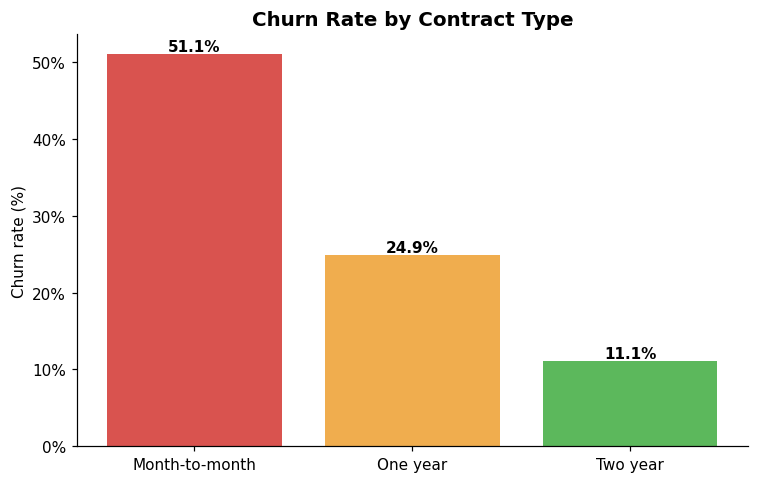

In [141]:
fig, ax = plt.subplots(figsize=(7, 4.5))
order = churn_by_contract.sort_values("churn_rate_pct", ascending=False)
bars = ax.bar(order["contract"], order["churn_rate_pct"], color=["#d9534f", "#f0ad4e", "#5cb85c"])
ax.set_ylabel("Churn rate (%)")
ax.set_title("Churn Rate by Contract Type", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
for b in bars:
    ax.annotate(f"{b.get_height():.1f}%", (b.get_x() + b.get_width()/2, b.get_height()),
                ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.savefig("chart_churn_by_contract.png", bbox_inches="tight")
plt.show()

### 5.2 Churn rate by tenure — risk is highest for new customers

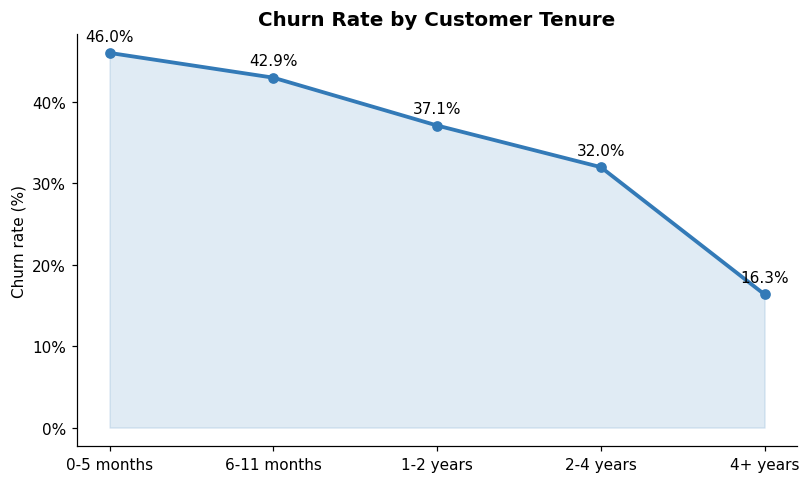

In [142]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
order = churn_by_tenure
ax.plot(order["tenure_bucket"], order["churn_rate_pct"], marker="o", linewidth=2.5, color="#337ab7")
ax.fill_between(range(len(order)), order["churn_rate_pct"], alpha=0.15, color="#337ab7")
ax.set_ylabel("Churn rate (%)")
ax.set_title("Churn Rate by Customer Tenure", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
for i, v in enumerate(order["churn_rate_pct"]):
    ax.annotate(f"{v:.1f}%", (i, v), textcoords="offset points", xytext=(0, 8), ha="center")
plt.tight_layout()
plt.savefig("chart_churn_by_tenure.png", bbox_inches="tight")
plt.show()

### 5.3 Monthly charges distribution: churned vs retained customers

/tmp/ipykernel_906/429448890.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=["Retained", "Churned"], patch_artist=True, widths=0.5)


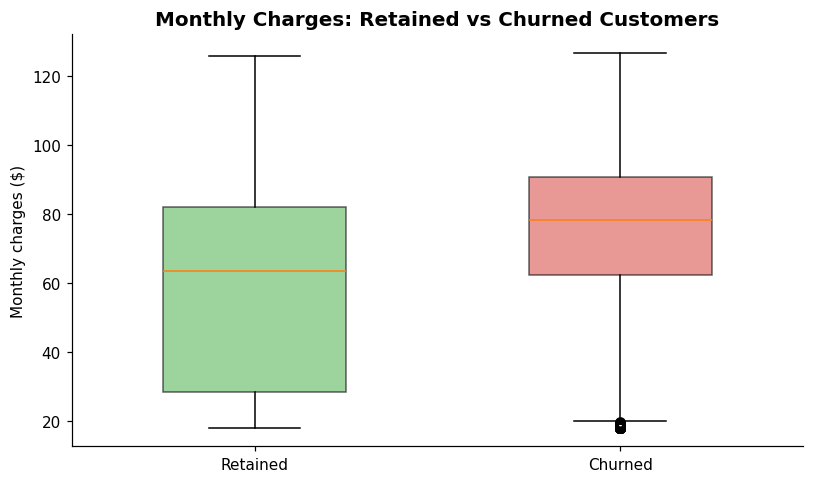

In [143]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
data_to_plot = [df.loc[df.churn == "No", "monthly_charges"], df.loc[df.churn == "Yes", "monthly_charges"]]
bp = ax.boxplot(data_to_plot, labels=["Retained", "Churned"], patch_artist=True, widths=0.5)
for patch, color in zip(bp["boxes"], ["#5cb85c", "#d9534f"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel("Monthly charges ($)")
ax.set_title("Monthly Charges: Retained vs Churned Customers", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("chart_charges_boxplot.png", bbox_inches="tight")
plt.show()

### 5.4 Top churn correlation factors

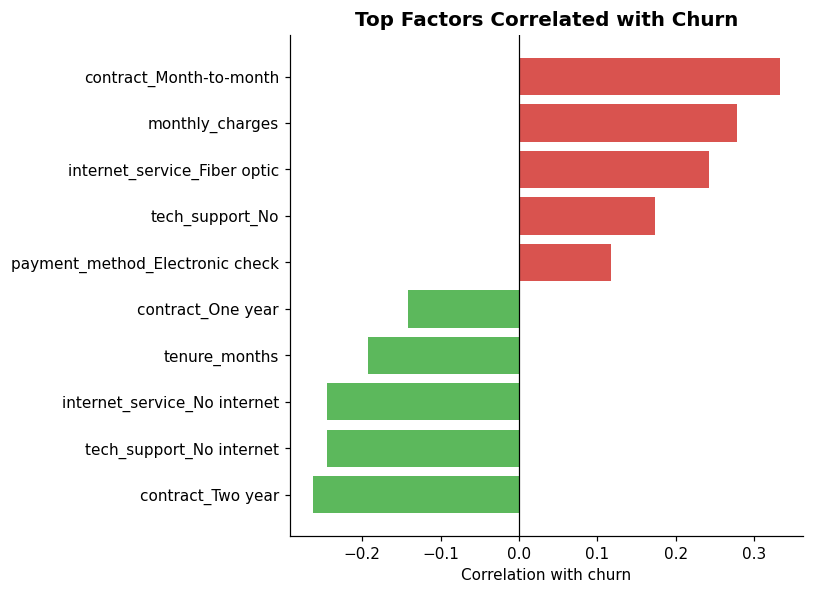

In [144]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
top_corr = corr_with_churn.head(10).sort_values()
colors = ["#d9534f" if v > 0 else "#5cb85c" for v in top_corr.values]
ax.barh(top_corr.index, top_corr.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Correlation with churn")
ax.set_title("Top Factors Correlated with Churn", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("chart_correlations.png", bbox_inches="tight")
plt.show()

### 5.5 Revenue at risk breakdown

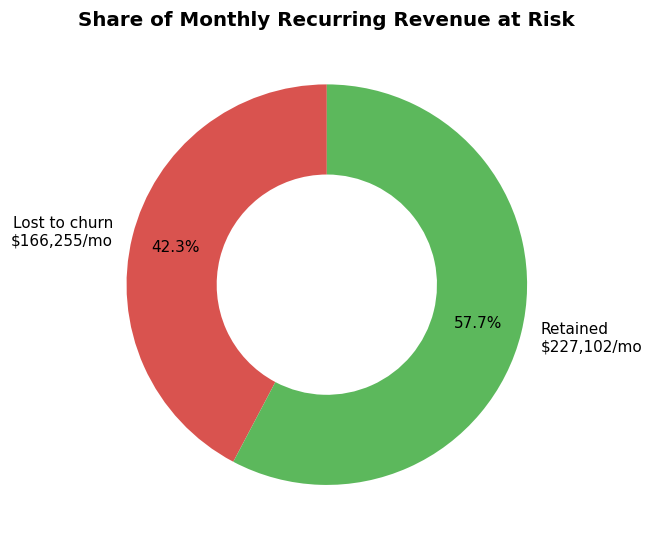

In [145]:
fig, ax = plt.subplots(figsize=(6, 6))
values = [float(revenue_at_risk["mrr_lost_to_churn"].iloc[0]),
          float(revenue_at_risk["total_mrr"].iloc[0]) - float(revenue_at_risk["mrr_lost_to_churn"].iloc[0])]
labels = [f"Lost to churn\n${values[0]:,.0f}/mo", f"Retained\n${values[1]:,.0f}/mo"]
ax.pie(values, labels=labels, colors=["#d9534f", "#5cb85c"], autopct="%1.1f%%",
       startangle=90, wedgeprops={"width": 0.45}, pctdistance=0.78)
ax.set_title("Share of Monthly Recurring Revenue at Risk", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("chart_revenue_at_risk.png", bbox_inches="tight")
plt.show()

### 5.6 Churn rate heatmap: contract × tech support

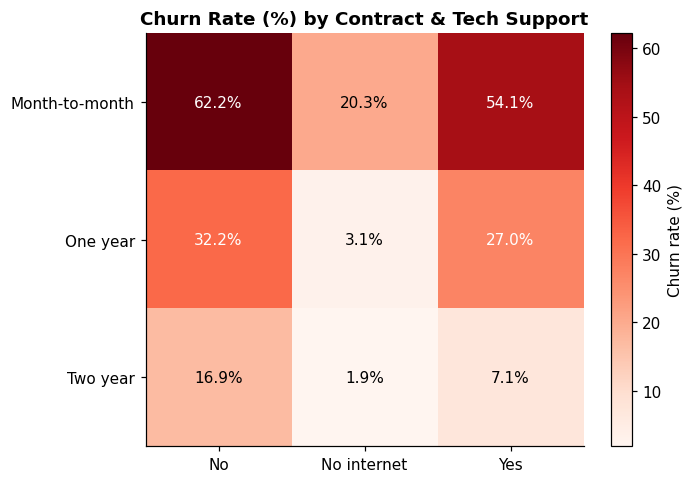

In [146]:
pivot = df.pivot_table(index="contract", columns="tech_support", values="churn_flag", aggfunc="mean") * 100
fig, ax = plt.subplots(figsize=(6.5, 4.5))
im = ax.imshow(pivot.values, cmap="Reds", aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_title("Churn Rate (%) by Contract & Tech Support", fontsize=12, fontweight="bold")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.1f}%", ha="center", va="center",
                     color="white" if val > pivot.values[~np.isnan(pivot.values)].mean() else "black")
fig.colorbar(im, ax=ax, label="Churn rate (%)")
plt.tight_layout()
plt.savefig("chart_heatmap.png", bbox_inches="tight")
plt.show()

## 6. Key Findings

1. **Contract type is the dominant churn driver.** Month-to-month customers churn at a far higher
   rate than one- or two-year contract holders — this is almost always fixable via pricing/incentive
   design, not product changes.
2. **Risk is front-loaded.** The first 6-11 months are the highest-risk window; customers who make it
   past year one are dramatically more likely to stay long-term.
3. **Lack of tech support compounds contract risk.** Month-to-month customers *without* tech support
   are the single highest-risk segment in the dataset.
4. **This isn't just a headcount problem — it's a revenue problem.** A meaningful share of monthly
   recurring revenue is walking out the door with churned customers, and it's concentrated in
   identifiable, addressable segments.
5. **Payment friction matters.** Customers on manual payment methods (electronic/mailed check) churn
   more than those on autopay — likely both a proxy for engagement and a literal reduction in the
   "friction to leave."

## 7. Recommendations

- **Targeted contract-upgrade campaign** for month-to-month customers in months 3-9 of tenure
  (before the highest-risk window), with a discount incentive to move to annual contracts.
- **Proactive tech-support outreach** for month-to-month customers without support plans —
  this is the highest-risk segment identified in section 3.6.
- **Autopay enrollment incentive** (small one-time credit) to reduce payment-method-driven churn.
- **Prioritize retention spend by revenue, not just churn probability** — section 3.5 shows we can't
  assume high spenders are automatically loyal; retention offers should be sized to customer value.
- **Watch the first 90 days closely** — an early-tenure "health check" outreach could catch
  at-risk new customers before they silently churn.

## 8. Bonus: A simple churn risk score (optional extension)

Beyond descriptive analysis, here's a lightweight logistic regression to turn these findings into a
**per-customer risk score** — the kind of output a retention team could actually act on. This step
uses scikit-learn, which pairs naturally with pandas/NumPy once you're comfortable with the basics above.

In [147]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report

model_df = pd.get_dummies(
    df[["tenure_months", "monthly_charges", "contract", "internet_service",
        "tech_support", "payment_method", "senior_citizen", "churn_flag"]],
    drop_first=True
)
X = model_df.drop(columns="churn_flag")
y = model_df["churn_flag"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_scaled, y_train)

y_pred_proba = clf.predict_proba(X_test_scaled)[:, 1]
y_pred = clf.predict(X_test_scaled)

print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}\n")
print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))

ROC-AUC: 0.797

              precision    recall  f1-score   support

    Retained       0.79      0.81      0.80       948
     Churned       0.65      0.63      0.64       552

    accuracy                           0.74      1500
   macro avg       0.72      0.72      0.72      1500
weighted avg       0.74      0.74      0.74      1500



### 8.1 Which features drive the model's predictions?

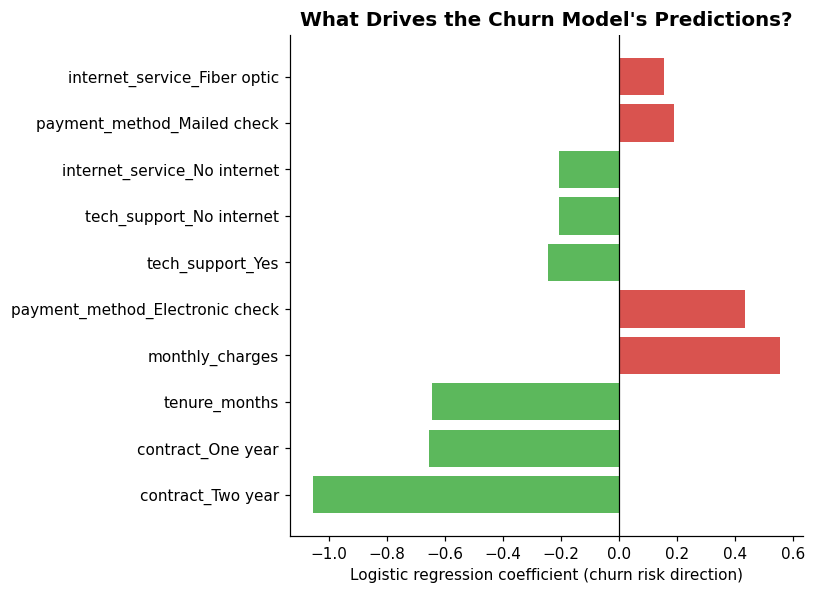

In [148]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": clf.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False).head(10)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
colors = ["#d9534f" if v > 0 else "#5cb85c" for v in coef_df["coefficient"]]
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Logistic regression coefficient (churn risk direction)")
ax.set_title("What Drives the Churn Model's Predictions?", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("chart_model_coefficients.png", bbox_inches="tight")
plt.show()

## 9. Next steps if you extend this project

- Swap in a **real dataset** (e.g. the IBM Telco Customer Churn dataset) once you're comfortable
  with this pipeline — the code above will work with minimal changes.
- Try **XGBoost/Random Forest** and compare against this logistic regression baseline.
- Build a small **Streamlit/Dash dashboard** on top of the SQL queries in section 3 for a portfolio
  piece that's interactive, not just a static notebook.
- Add a **cost-benefit model**: estimate retention-campaign cost vs. revenue saved per segment,
  and rank segments by ROI rather than churn rate alone.

conn.close()